In [1]:
#CodeCarbon
# !pip install codecarbon
# !pip install --upgrade codecarbon
# !pip install --upgrade codecarbon --quiet


In [18]:


import json
data1 = {
    "id": 1,
    "gaz_sarfi": 42.5,         # metrlarda
    "oylik_tolov": 10000,     # so‘m
    "real_tolov": 70000        # so‘m
}


In [20]:
import pandas as pd

data = {
    "oy": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "harorat": [-5, -2, 5, 12, 20, 25, 30, 28, 22, 15, 5, -3],  # O‘rtacha harorat
    "gaz_sarfi": [65, 60, 50, 40, 30, 20, 18, 19, 25, 40, 55, 62]  # Gaz sarfi m³
}

df = pd.DataFrame(data)
df


,oy,harorat,gaz_sarfi
0,1,-5,65
1,2,-2,60
2,3,5,50
3,4,12,40
4,5,20,30
5,6,25,20
6,7,30,18
7,8,28,19
8,9,22,25
9,10,15,40


In [21]:
#regression
X = df[["oy", "harorat"]]
y = df["gaz_sarfi"]

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

prognoz = model.predict([[1, -4]])
print(f"Kelajakdagi gaz sarfi bashorati: {prognoz[0]:.2f} m³")




Kelajakdagi gaz sarfi bashorati: 62.69 m³


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
print(f"MSE: {mse:.2f}")


MSE: 3.00


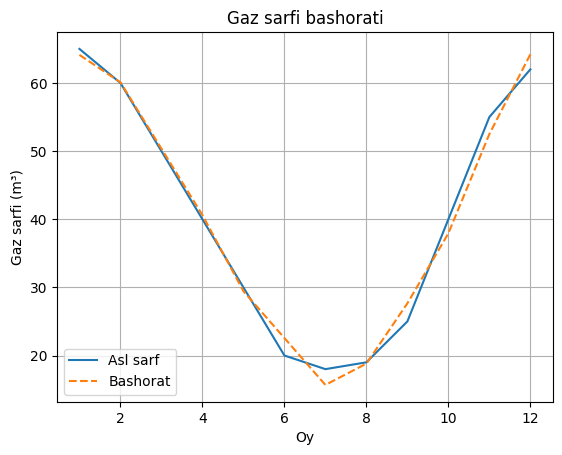

In [23]:
import matplotlib.pyplot as plt

plt.plot(df["oy"], y, label="Asl sarf")
plt.plot(df["oy"], y_pred, label="Bashorat", linestyle="--")
plt.xlabel("Oy")
plt.ylabel("Gaz sarfi (m³)")
plt.title("Gaz sarfi bashorati")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
with open("abonent1.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=4)
print("Fayl saqlandi: abonent1.json")


Fayl saqlandi: abonent1.json


In [25]:
def tekshir_qarz(gaz_sarfi, oylik_tolov, real_tolov, threshold=0.2):
    qarz = oylik_tolov - real_tolov
    foiz = qarz / oylik_tolov

    if foiz > threshold:
        return f"Diqqat! Siz {foiz*100:.1f}% yetarli to‘lov qilmagansiz. Qarzingiz: {qarz} so‘m."
    else:
        return "To‘lov normal holatda. Rahmat!"


In [27]:
xabar = tekshir_qarz(
    gaz_sarfi=data1["gaz_sarfi"],
    oylik_tolov=data1["oylik_tolov"],
    real_tolov=data1["real_tolov"]
    ),

print("Yuboriladigan xabar:", xabar)


Yuboriladigan xabar: ('To‘lov normal holatda. Rahmat!',)


In [28]:
import requests

def telegram_xabar_yubor(text, token, chat_id):
    url = f"https://api.telegram.org/bot{token}/sendMessage"
    payload = {"chat_id": chat_id, "text": text}
    response = requests.post(url, data=payload)
    return response.status_code


In [29]:
import requests

TOKEN = "7595968854:AAFvU3CVIaqrecNDFFok26rIk7AnNLsH1ko"  #

url = f"https://api.telegram.org/bot{TOKEN}/getUpdates"
response = requests.get(url)
print(response.json())


{'ok': True, 'result': []}


In [30]:
my_token = "7595968854:AAFvU3CVIaqrecNDFFok26rIk7AnNLsH1ko"
my_chat_id = "1699585304"

telegram_xabar_yubor(xabar, my_token, my_chat_id)


200